In this notebook ,we will explore the train dataset here before modeling. We want to make sure the data is clean, scaled, and ready to use for modeling.

In [2]:
# imports
import numpy as np
import pandas as pd

# plotting Libraries
import seaborn as sns
import matplotlib.pyplot as plt

In [3]:
df = pd.read_csv('../data/train.csv')
df.head(5)

,id,Time,feat1,feat2,feat3,feat4,feat5,feat6,feat7,feat8,...,feat21,feat22,feat23,feat24,feat25,feat26,feat27,feat28,Transaction_Amount,IsFraud
0,0,0.0,2.074329,-0.129425,-1.137418,0.412846,-0.192638,-1.210144,0.110697,-0.263477,...,-0.334701,-0.887840,0.336701,-0.110835,-0.291459,0.207733,-0.076576,-0.059577,1.98,0
1,1,0.0,1.998827,-1.250891,-0.520969,-0.894539,-1.122528,-0.270866,-1.029289,0.050198,...,0.054848,-0.038367,0.133518,-0.461928,-0.465491,-0.464655,-0.009413,-0.038238,84.00,0
2,2,0.0,0.091535,1.004517,-0.223445,-0.435249,0.667548,-0.988351,0.948146,-0.084789,...,-0.326725,-0.803736,0.154495,0.951233,-0.506919,0.085046,0.224458,0.087356,2.69,0
3,3,0.0,1.979649,-0.184949,-1.064206,0.120125,-0.215238,-0.648829,-0.087826,-0.035367,...,-0.095514,-0.079792,0.167701,-0.042939,0.000799,-0.096148,-0.057780,-0.073839,1.00,0
4,4,0.0,1.025898,-0.171827,1.203717,1.243900,-0.636572,1.099074,-0.938651,0.569239,...,0.099157,0.608908,0.027901,-0.262813,0.257834,-0.252829,0.108338,0.021051,1.00,0


In [4]:
# checking the number of rows, data types and null values
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150000 entries, 0 to 149999
Data columns (total 32 columns):
 #   Column              Non-Null Count   Dtype  
---  ------              --------------   -----  
 0   id                  150000 non-null  int64  
 1   Time                150000 non-null  float64
 2   feat1               150000 non-null  float64
 3   feat2               150000 non-null  float64
 4   feat3               150000 non-null  float64
 5   feat4               150000 non-null  float64
 6   feat5               150000 non-null  float64
 7   feat6               150000 non-null  float64
 8   feat7               150000 non-null  float64
 9   feat8               150000 non-null  float64
 10  feat9               150000 non-null  float64
 11  feat10              150000 non-null  float64
 12  feat11              150000 non-null  float64
 13  feat12              150000 non-null  float64
 14  feat13              150000 non-null  float64
 15  feat14              150000 non-nul

 We see that the data is complete and has no nulls. There are 150,000 rows with float and int data types.

In [5]:
# checking null values
df.isnull().sum().sum()

np.int64(0)

In [6]:
df.describe()

,id,Time,feat1,feat2,feat3,feat4,feat5,feat6,feat7,feat8,...,feat21,feat22,feat23,feat24,feat25,feat26,feat27,feat28,Transaction_Amount,IsFraud
count,150000.000000,150000.000000,150000.000000,150000.000000,150000.000000,150000.000000,150000.000000,150000.000000,150000.000000,150000.000000,...,150000.000000,150000.000000,150000.000000,150000.000000,150000.000000,150000.000000,150000.000000,150000.000000,150000.000000,150000.000000
mean,74999.500000,49785.422340,0.069456,-0.003674,0.739860,0.104810,-0.254623,0.151934,-0.165443,0.166254,...,-0.032077,-0.068876,-0.059646,-0.000776,0.161152,0.021575,0.014138,0.020323,71.065194,0.001793
std,43301.414527,18733.655609,1.346553,1.161502,1.012801,1.230909,1.048268,1.182964,0.802668,0.691267,...,0.404916,0.573755,0.323272,0.584270,0.385175,0.473795,0.223692,0.163429,158.712510,0.042310
min,0.000000,0.000000,-22.173926,-44.247914,-19.088980,-5.069484,-21.090735,-25.659750,-31.179799,-28.903442,...,-14.689621,-7.351378,-11.958588,-2.827444,-3.958591,-1.413857,-9.234767,-4.454059,0.000000,0.000000
25%,37499.750000,39411.000000,-0.844248,-0.621724,0.181373,-0.738399,-0.912254,-0.590892,-0.667139,-0.078114,...,-0.185077,-0.464426,-0.177546,-0.321495,-0.078682,-0.310948,-0.044800,0.001623,6.990000,0.000000
50%,74999.500000,53785.000000,0.671327,0.003677,0.826497,0.095342,-0.322525,-0.068690,-0.144551,0.125052,...,-0.044828,-0.045844,-0.068170,0.043048,0.181701,-0.087927,0.017590,0.024098,24.900000,0.000000
75%,112499.250000,63833.000000,1.171271,0.753340,1.360362,0.967657,0.242796,0.492931,0.334553,0.396056,...,0.100896,0.309938,0.047399,0.388969,0.425791,0.269844,0.073776,0.065778,74.000000,0.000000
max,149999.000000,73899.000000,2.390816,16.068473,6.145578,12.547997,34.581260,15.082516,23.256066,18.270586,...,22.062945,6.163541,12.734391,4.572739,3.111624,3.119824,6.457839,23.263746,6513.350000,1.000000



All features are scaled except for the 'Time' and the 'Transaction_Amount' features. For better model calculations 'Time' and the 'Transaction_Amount' should also be scaled. The 'id' column should be dropped from the features before modeling. We will do it in the rest notebooks.

In [7]:
# checking the target feature balance
print('Number of observations:', len(df))
print('Number of fraud cases:', df.IsFraud.sum())
print('Share of fraud cases:', format((df.IsFraud.sum() / len(df)) , ".3%"))
print('Share of non-fraud cases:', format(((len(df)-df.IsFraud.sum()) / len(df)) , ".3%"))

Number of observations: 150000
Number of fraud cases: 269
Share of fraud cases: 0.179%
Share of non-fraud cases: 99.821%


As we can see, we have an extremely imbalanced dataset here, with even less than 1%, 0.5%, and 0.25% of target (fraud) observations out of the total observations!

C:\Users\tinew\AppData\Local\Temp\ipykernel_57136\1512835999.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='IsFraud', data=df, palette=colors)


Text(0.5, 1.0, 'Class Distributions')

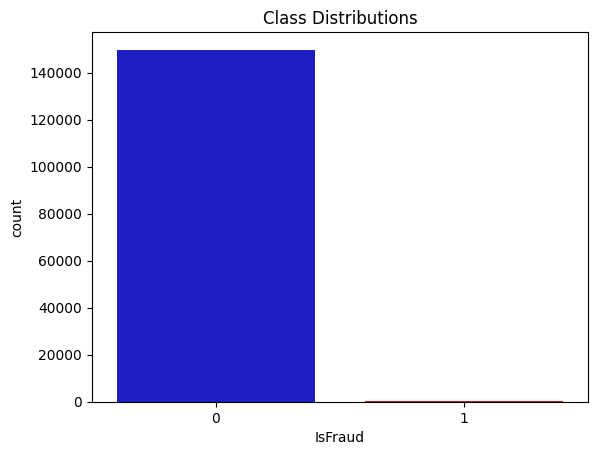

In [8]:
# Fraud / non Fraud count plot
colors = ["#0101DF", "#DF0101"]

sns.countplot(x='IsFraud', data=df, palette=colors)
plt.title('Class Distributions')

Let's take a look at the hists plot.

array([[<Axes: title={'center': 'id'}>, <Axes: title={'center': 'Time'}>,
        <Axes: title={'center': 'feat1'}>,
        <Axes: title={'center': 'feat2'}>,
        <Axes: title={'center': 'feat3'}>,
        <Axes: title={'center': 'feat4'}>],
       [<Axes: title={'center': 'feat5'}>,
        <Axes: title={'center': 'feat6'}>,
        <Axes: title={'center': 'feat7'}>,
        <Axes: title={'center': 'feat8'}>,
        <Axes: title={'center': 'feat9'}>,
        <Axes: title={'center': 'feat10'}>],
       [<Axes: title={'center': 'feat11'}>,
        <Axes: title={'center': 'feat12'}>,
        <Axes: title={'center': 'feat13'}>,
        <Axes: title={'center': 'feat14'}>,
        <Axes: title={'center': 'feat15'}>,
        <Axes: title={'center': 'feat16'}>],
       [<Axes: title={'center': 'feat17'}>,
        <Axes: title={'center': 'feat18'}>,
        <Axes: title={'center': 'feat19'}>,
        <Axes: title={'center': 'feat20'}>,
        <Axes: title={'center': 'feat21'}>,
        

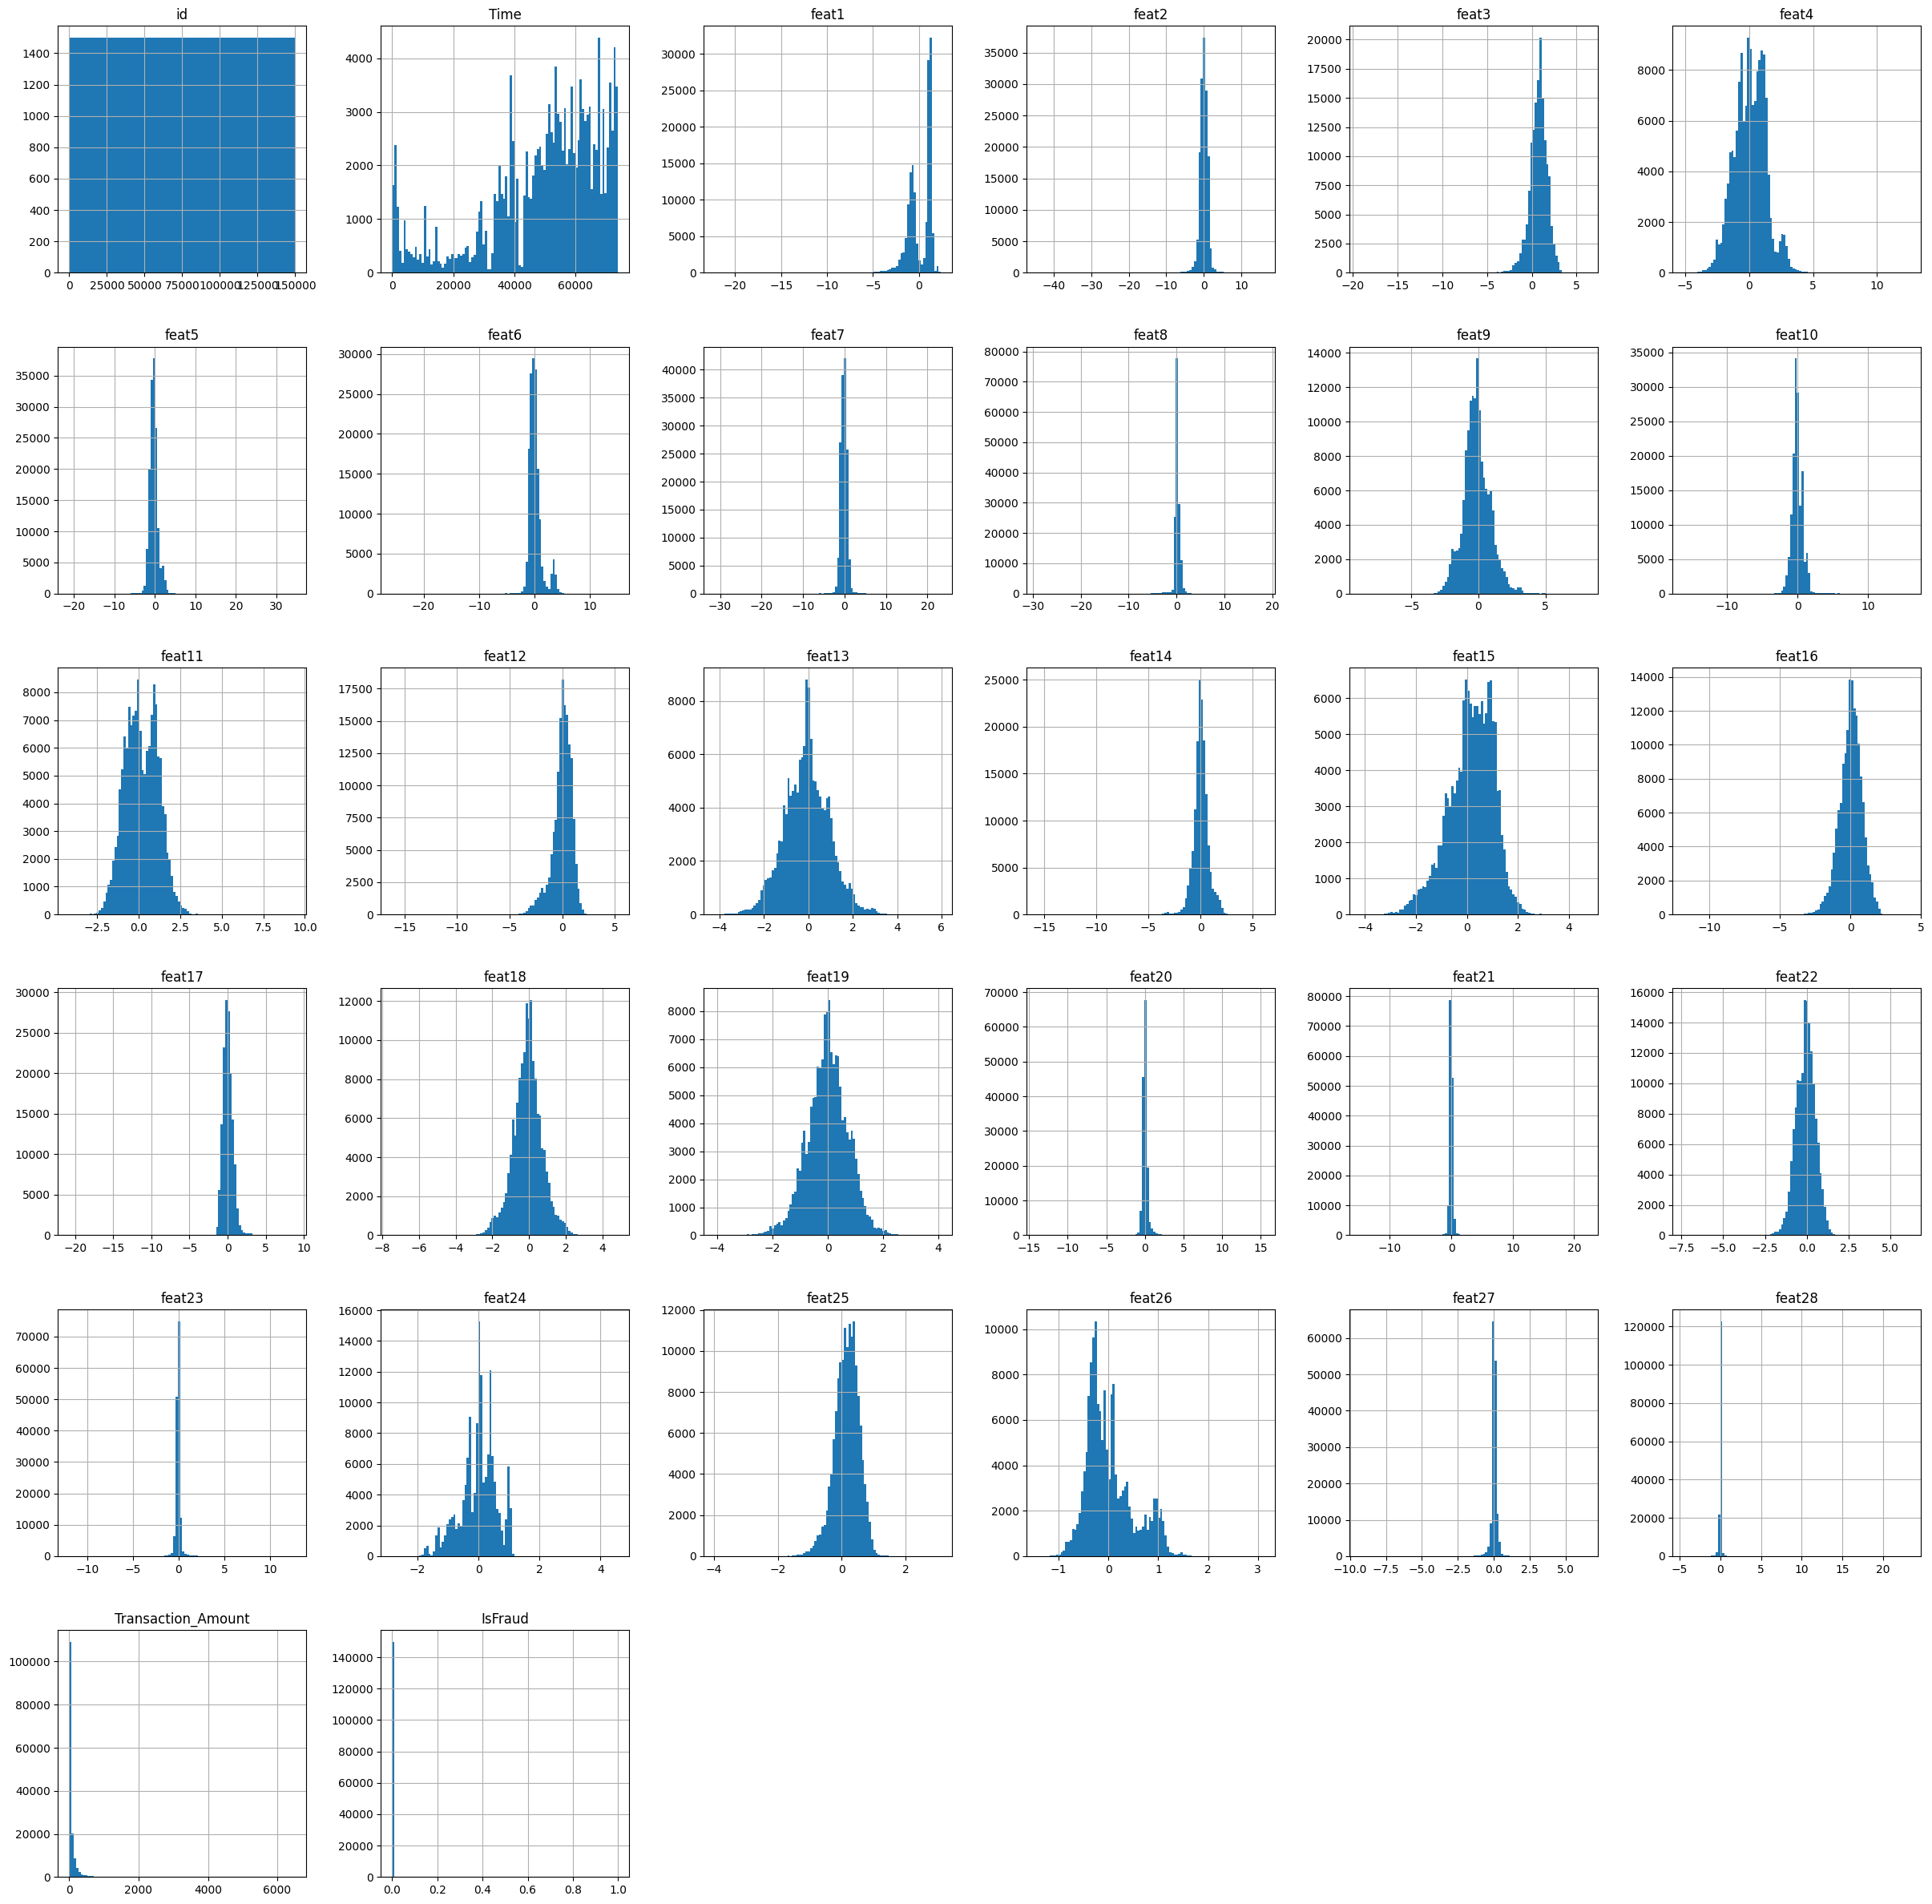

In [9]:
df.hist(bins=100, figsize=(30,30))

The 'Time' and the 'Transaction_Amount' features have not been scaled. Let's take a closer look at them.

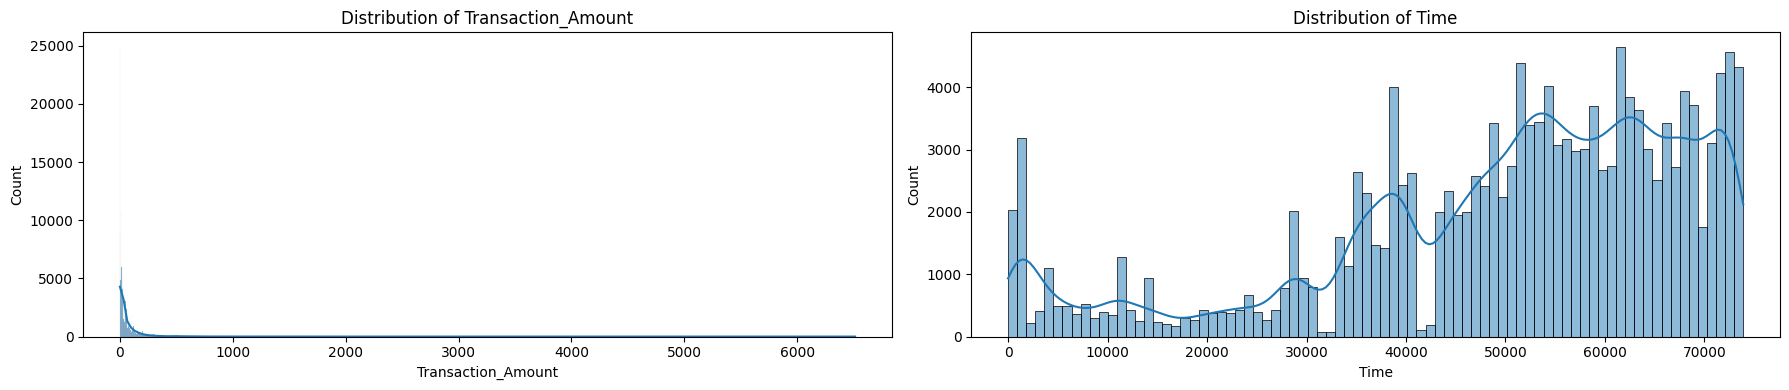

In [10]:
# Transactional amount + Time
fig, axes = plt.subplots(1, 2, figsize=(18, 4))
for ax, col in zip(axes, ["Transaction_Amount", "Time"]):
    sns.histplot(df[col], kde=True, ax=ax).set_title(f"Distribution of {col}")
plt.tight_layout()

# Conclusion

We have clean data without nulls. It is an extremely imbalanced dataset, which requires the use of specific techniques to build reliable models. All features except 'Time' and 'Transaction_amount' have been scaled. We will scale them in the modeling notebooks: 02_random_forest_undersample.ipynb and 03_xgb_fulldata.ipynb

Let's move on to building our first model 02_random_forest_undersample.ipynb